You are given an m x n matrix grid of positive integers. Your task is to determine if it is possible to make either one horizontal or one vertical cut on the grid such that:

    Each of the two resulting sections formed by the cut is non-empty.
    The sum of elements in both sections is equal, or can be made equal by discounting at most one single cell in total (from either section).
    If a cell is discounted, the rest of the section must remain connected.

Return true if such a partition exists; otherwise, return false.

Note: A section is connected if every cell in it can be reached from any other cell by moving up, down, left, or right through other cells in the section.

 

Example 1:

Input: grid = [[1,4],[2,3]]

Output: true

Explanation:

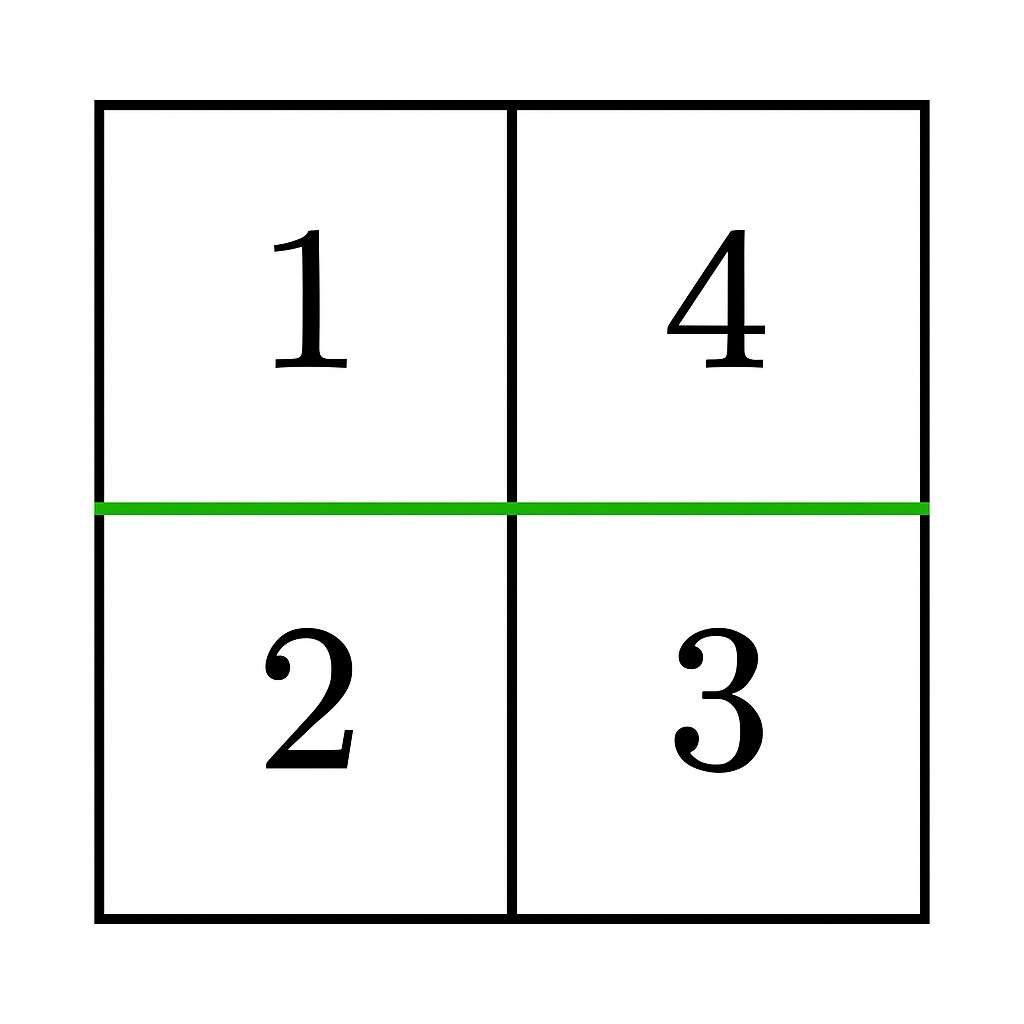

    A horizontal cut after the first row gives sums 1 + 4 = 5 and 2 + 3 = 5, which are equal. Thus, the answer is true.

Example 2:

Input: grid = [[1,2],[3,4]]

Output: true

Explanation:

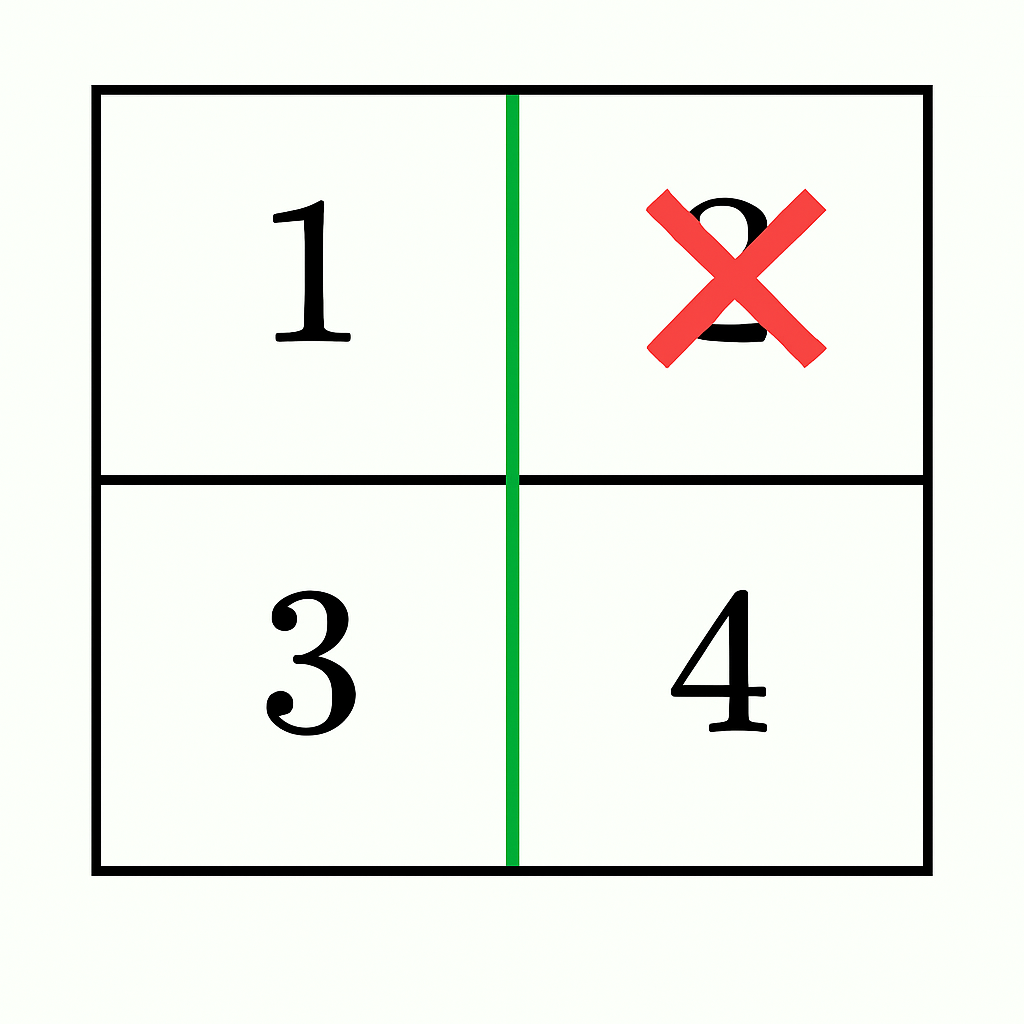

    A vertical cut after the first column gives sums 1 + 3 = 4 and 2 + 4 = 6.
    By discounting 2 from the right section (6 - 2 = 4), both sections have equal sums and remain connected. Thus, the answer is true.

Example 3:

Input: grid = [[1,2,4],[2,3,5]]

Output: false

Explanation:

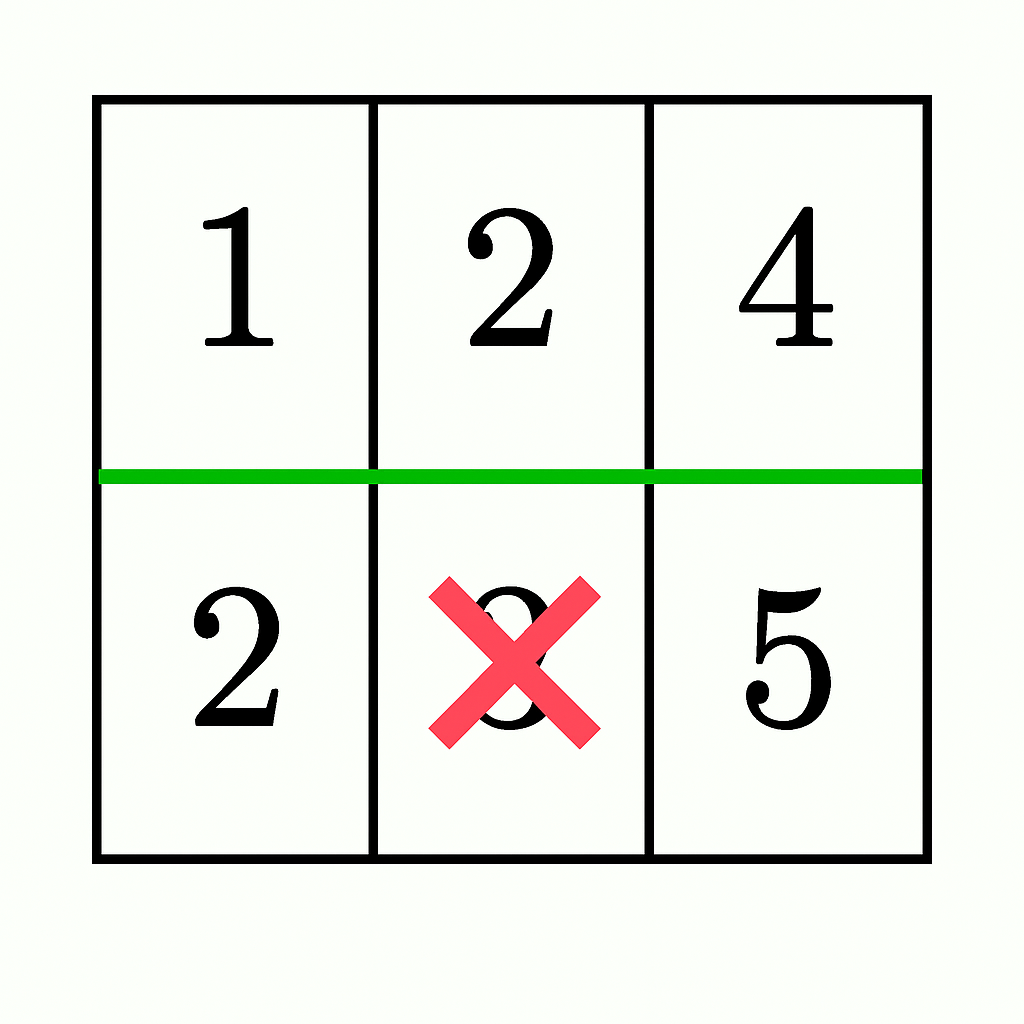

    A horizontal cut after the first row gives 1 + 2 + 4 = 7 and 2 + 3 + 5 = 10.
    By discounting 3 from the bottom section (10 - 3 = 7), both sections have equal sums, but they do not remain connected as it splits the bottom section into two parts ([2] and [5]). Thus, the answer is false.

Example 4:

Input: grid = [[4,1,8],[3,2,6]]

Output: false

Explanation:

No valid cut exists, so the answer is false.

 

Constraints:

    1 <= m == grid.length <= 105
    1 <= n == grid[i].length <= 105
    2 <= m * n <= 105
    1 <= grid[i][j] <= 105



In [ ]:
class Solution:
    def canPartitionGrid(self, grid: List[List[int]]) -> bool:
        total = 0
        m = len(grid)
        n = len(grid[0])
        for i in range(m):
            for j in range(n):
                total += grid[i][j]
        for _ in range(4):
            exist = set()
            exist.add(0)
            sum_val = 0
            m = len(grid)
            n = len(grid[0])
            if m < 2:
                grid = self.rotation(grid)
                continue
            if n == 1:
                for i in range(m - 1):
                    sum_val += grid[i][0]
                    tag = sum_val * 2 - total
                    if tag == 0 or tag == grid[0][0] or tag == grid[i][0]:
                        return True
                grid = self.rotation(grid)
                continue
            for i in range(m - 1):
                for j in range(n):
                    exist.add(grid[i][j])
                    sum_val += grid[i][j]
                tag = sum_val * 2 - total
                if i == 0:
                    if tag == 0 or tag == grid[0][0] or tag == grid[0][n - 1]:
                        return True
                    continue
                if tag in exist:
                    return True
            grid = self.rotation(grid)
        return False

    def rotation(self, grid: List[List[int]]) -> List[List[int]]:
        m = len(grid)
        n = len(grid[0])
        tmp = [[0] * m for _ in range(n)]
        for i in range(m):
            for j in range(n):
                tmp[j][m - 1 - i] = grid[i][j]
        return tmp